In [1]:
import os
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Conv2D
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder

2026-03-28 19:00:32.158577: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774724432.635594      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774724432.760484      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
base_dir = "/kaggle/input/cxr-ct-cough/processed_dataset/processed_dataset"
modalities = ["CT", "CXR", "Cough sound"]
classes = ["covid", "Healthy", "LungsCancer", "Pneumonia"]

IMG_SIZE = 224

In [3]:
X = []
y = []

for cls_idx, cls in enumerate(classes):
   
    filenames = sorted(os.listdir(os.path.join(base_dir, modalities[0], cls)))
    
    for file_name in filenames:
        imgs = []
        skip = False
        for m in modalities:
            path = os.path.join(base_dir, m, cls, file_name)
            if not os.path.exists(path):
                skip = True
                break
            img = cv2.imread(path)
            if img is None:
                skip = True
                break
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            imgs.append(img)
        
        if skip:  
            continue
        
       
        fused = np.concatenate(imgs, axis=-1)  
        X.append(fused)
        y.append(cls_idx)

X = np.array(X, dtype='float32') / 255.0
y = to_categorical(np.array(y), num_classes=len(classes))

print(f" Data loaded: {X.shape[0]} samples, shape per sample: {X.shape[1:]}")


 Data loaded: 2000 samples, shape per sample: (224, 224, 9)


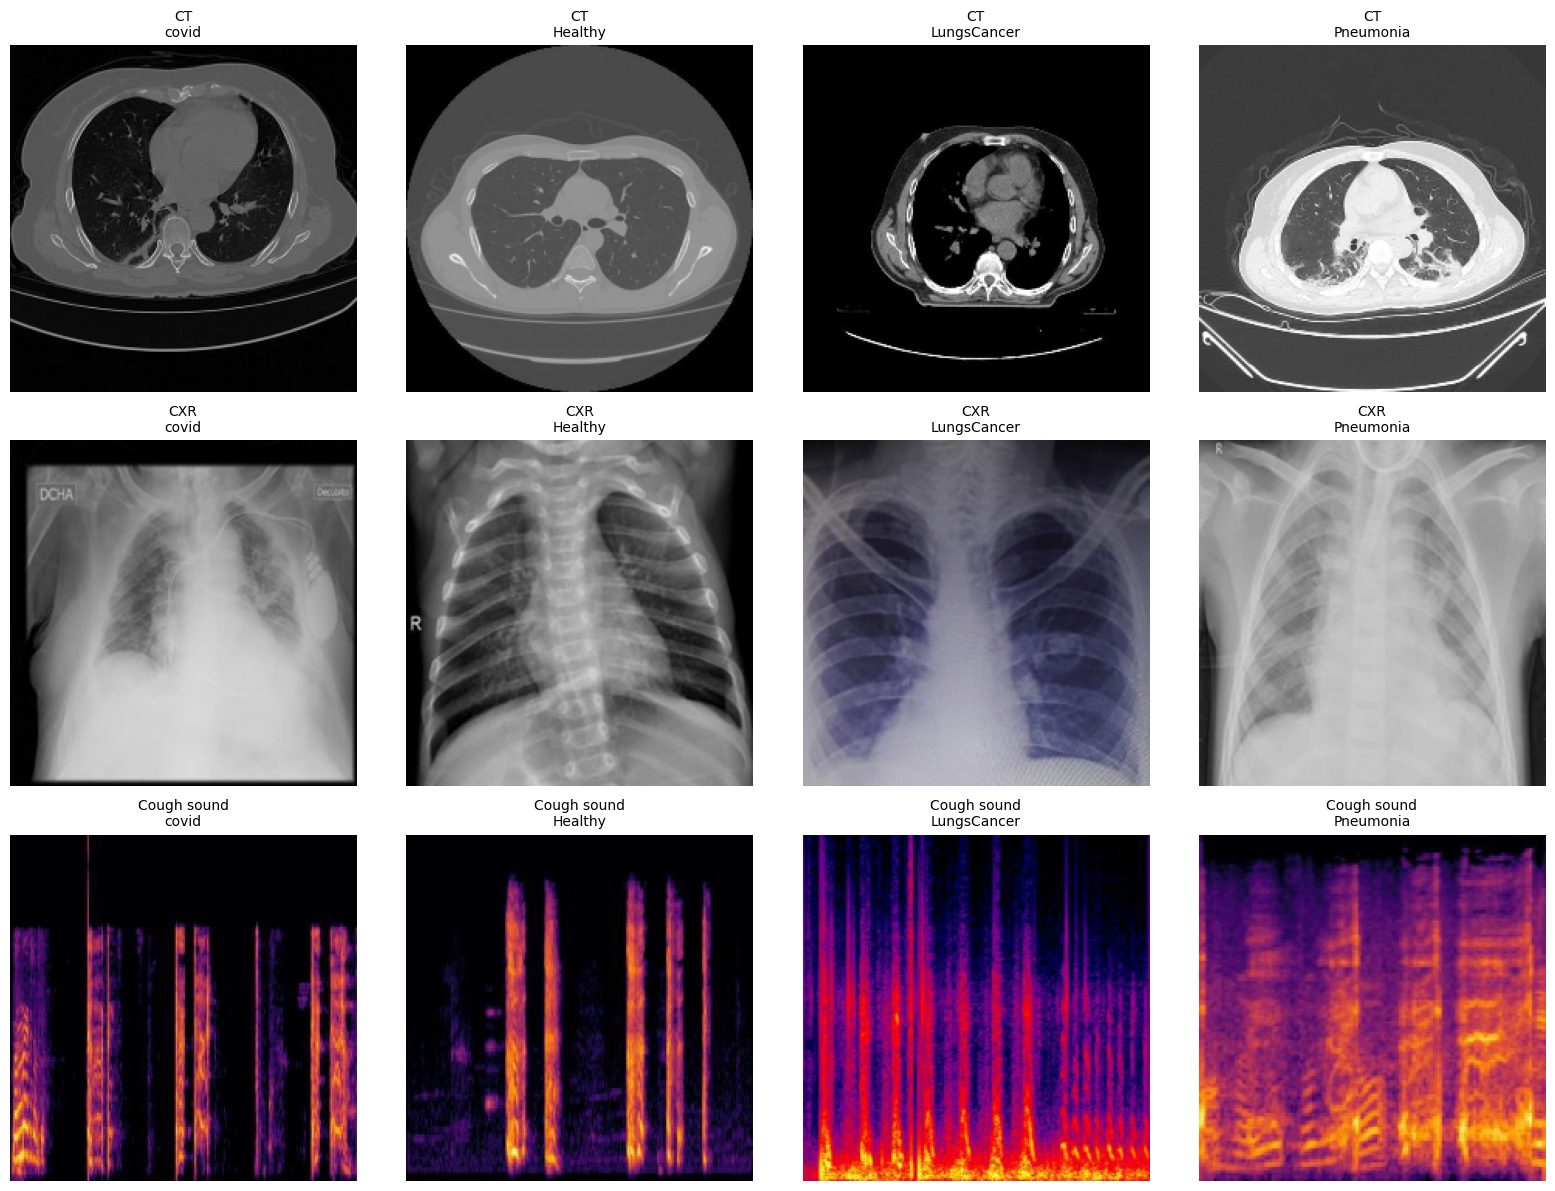

In [4]:
import os
import cv2
import matplotlib.pyplot as plt
import random


plt.figure(figsize=(16, 12))


img_index = 1
for m in modalities:
    for cls in classes:
        folder_path = os.path.join(base_dir, m, cls)
        if not os.path.exists(folder_path):
            print(f"⚠️  path not found : {folder_path}")
            continue
        
        files = os.listdir(folder_path)
        if len(files) == 0:
            print(f"⚠️ image not found in : {folder_path}")
            continue

       
        random_file = random.choice(files)
        img_path = os.path.join(folder_path, random_file)

        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        plt.subplot(len(modalities), len(classes), img_index)
        plt.imshow(img)
        plt.title(f"{m}\n{cls}", fontsize=10)
        plt.axis("off")

        img_index += 1

plt.tight_layout()
plt.show()


In [5]:
input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 9))


x = Conv2D(3, (1,1), padding='same', activation='relu')(input_tensor)


base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(x)
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(len(classes), activation='softmax')(x)

model = Model(inputs=input_tensor, outputs=output)


for layer in base_model.layers:
    layer.trainable = False

I0000 00:00:1774724531.258938      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774724531.261804      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [6]:
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 9)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 3)    │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,314 (91.98 MB)

 Trainable params: 525,602 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
 

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

checkpoint = ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
earlystop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [9]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=16,
    callbacks=[checkpoint, earlystop],
    verbose=1
)

Epoch 1/20


I0000 00:00:1774724551.389645      69 service.cc:148] XLA service 0x7c808c006d40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774724551.391509      69 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774724551.391533      69 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774724552.873135      69 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/80 ━━━━━━━━━━━━━━━━━━━━ 25:22 19s/step - accuracy: 0.2500 - loss: 1.8166

I0000 00:00:1774724560.495267      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.2535 - loss: 1.6190
Epoch 1: val_accuracy improved from -inf to 0.20937, saving model to best_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 34s 186ms/step - accuracy: 0.2535 - loss: 1.6181 - val_accuracy: 0.2094 - val_loss: 1.3984
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.2490 - loss: 1.4831
Epoch 2: val_accuracy did not improve from 0.20937
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.2490 - loss: 1.4831 - val_accuracy: 0.2094 - val_loss: 1.4132
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.2847 - loss: 1.4459
Epoch 3: val_accuracy improved from 0.20937 to 0.24688, saving model to best_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - accuracy: 0.2845 - loss: 1.4458 - val_accuracy: 0.2469 - val_loss: 1.3761
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.2471 - loss: 1.4320
Epoch 4: val_accuracy improved from 0.24688 to 0.31563, saving model to best_model.h5
80/80 ━━━━━━━

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")


13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 204ms/step - accuracy: 0.8009 - loss: 0.6602

Test Accuracy: 80.00%


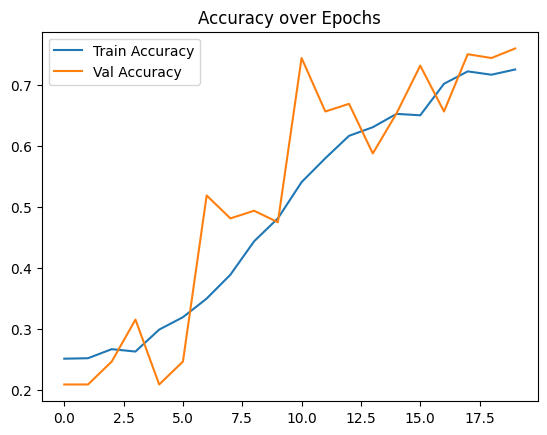

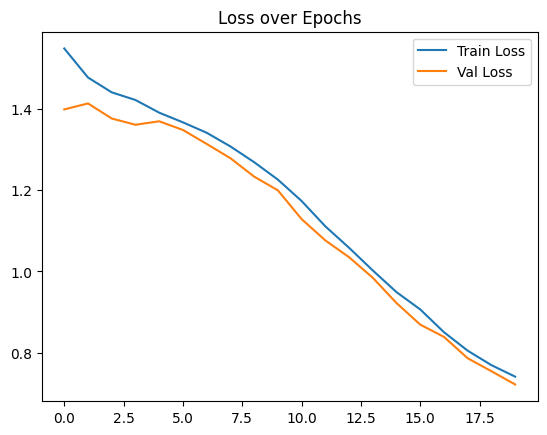

In [11]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy over Epochs")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss over Epochs")
plt.show()


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes, target_names=classes))


13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 459ms/step
              precision    recall  f1-score   support

       covid       0.64      0.76      0.69       100
     Healthy       0.74      0.67      0.71       100
 LungsCancer       0.95      0.80      0.87       100
   Pneumonia       0.91      0.97      0.94       100

    accuracy                           0.80       400
   macro avg       0.81      0.80      0.80       400
weighted avg       0.81      0.80      0.80       400



In [13]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Concatenate
n_classes = 4
IMG_SIZE = 224

base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
for layer in base_vgg.layers:
    layer.trainable = False

input_cxr = Input(shape=(224,224,3), name='CXR_Input')
input_ct = Input(shape=(224,224,3), name='CT_Input')
input_cough = Input(shape=(224,224,3), name='Cough_Input')

feat_cxr = base_vgg(input_cxr)
feat_ct = base_vgg(input_ct)
feat_cough = base_vgg(input_cough)

feat_cxr = GlobalAveragePooling2D()(feat_cxr)
feat_ct = GlobalAveragePooling2D()(feat_ct)
feat_cough = GlobalAveragePooling2D()(feat_cough)

merged_intermediate= Concatenate()([feat_cxr, feat_ct, feat_cough])
x_intermediate = Dense(256, activation='relu')(merged_intermediate)
x_intermediate = Dropout(0.3)(x_intermediate)
output_early = Dense(n_classes, activation='softmax')(x_intermediate)

intermediate_model = Model(inputs=[input_cxr, input_ct, input_cough], outputs=output_early)
intermediate_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

intermediate_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ CXR_Input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CT_Input            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Cough_Input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ CXR_Input[0][0],  │
│                     │                   │            │ CT_Input[0][0],   │
│                     │                   │            │ Cough_Input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[1][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[2][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1536)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
│                     │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    393,472 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │      1,028 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,109,188 (57.64 MB)

 Trainable params: 394,500 (1.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [14]:
IMG_SIZE = 224
modalities = ['CT', 'CXR', 'Cough sound']
classes = ["covid", "Healthy", "LungsCancer", "Pneumonia"]
base_dir = "/kaggle/input/cxr-ct-cough/processed_dataset/processed_dataset"

X_ct, X_cxr, X_cough, y = [], [], [], []

for cls_idx, cls in enumerate(classes):
    filenames = sorted(os.listdir(os.path.join(base_dir, modalities[0], cls)))
    
    for file_name in filenames:
        imgs = {}
        skip = False
        for m in modalities:
            path = os.path.join(base_dir, m, cls, file_name)
            if not os.path.exists(path):
                skip = True
                break
            img = cv2.imread(path)
            if img is None:
                skip = True
                break
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            imgs[m] = img
        
        if skip:
            continue
        
        X_ct.append(imgs['CT'])
        X_cxr.append(imgs['CXR'])
        X_cough.append(imgs['Cough sound'])
        y.append(cls_idx)

X_ct = np.array(X_ct, dtype='float32') / 255.0
X_cxr = np.array(X_cxr, dtype='float32') / 255.0
X_cough = np.array(X_cough, dtype='float32') / 255.0
y = to_categorical(np.array(y), num_classes=len(classes))

print(f" Data loaded successfully!")
print(f"CT: {X_ct.shape}, CXR: {X_cxr.shape}, Cough: {X_cough.shape}, Labels: {y.shape}")


 Data loaded successfully!
CT: (2000, 224, 224, 3), CXR: (2000, 224, 224, 3), Cough: (2000, 224, 224, 3), Labels: (2000, 4)


In [15]:
from sklearn.model_selection import train_test_split

print("Before split:", y.shape)


X_ct_train, X_ct_test, X_cxr_train, X_cxr_test, X_cough_train, X_cough_test, y_train, y_test = train_test_split(
    X_ct, X_cxr, X_cough, y, test_size=0.2, random_state=42, stratify=y.argmax(axis=1)
)

print("After split:")
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Before split: (2000, 4)
After split:
y_train: (1600, 4)
y_test: (400, 4)


In [16]:
history = intermediate_model.fit(
    [X_ct_train, X_cxr_train, X_cough_train],
    y_train,
    validation_data=([X_ct_test, X_cxr_test, X_cough_test], y_test),
    epochs=20,
    batch_size=16
)


Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 57s 439ms/step - accuracy: 0.5782 - loss: 1.0387 - val_accuracy: 0.9025 - val_loss: 0.3069
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 390ms/step - accuracy: 0.8829 - loss: 0.3185 - val_accuracy: 0.9225 - val_loss: 0.2092
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 397ms/step - accuracy: 0.9441 - loss: 0.1940 - val_accuracy: 0.9150 - val_loss: 0.2022
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 393ms/step - accuracy: 0.9288 - loss: 0.1936 - val_accuracy: 0.9475 - val_loss: 0.1404
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 391ms/step - accuracy: 0.9403 - loss: 0.1748 - val_accuracy: 0.9475 - val_loss: 0.1524
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 391ms/step - accuracy: 0.9446 - loss: 0.1341 - val_accuracy: 0.9550 - val_loss: 0.1086
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 392ms/step - accuracy: 0.9469 - loss: 0.1347 - val_accuracy: 0.9625 - val_loss: 0.1079
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 393ms/step - accuracy: 0.9587 - loss: 0

In [17]:
test_loss, test_acc = intermediate_model.evaluate([X_ct_test, X_cxr_test, X_cough_test], y_test)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")


13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 601ms/step - accuracy: 0.9780 - loss: 0.0588

Test Accuracy: 97.25%


In [18]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = intermediate_model.predict([X_ct_test, X_cxr_test, X_cough_test])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)


print("=== Classification Report ===")
print(classification_report(y_true, y_pred_classes, target_names=classes))


13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 689ms/step
=== Classification Report ===
              precision    recall  f1-score   support

       covid       0.93      0.96      0.95       100
     Healthy       0.97      0.93      0.95       100
 LungsCancer       0.99      1.00      1.00       100
   Pneumonia       1.00      1.00      1.00       100

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



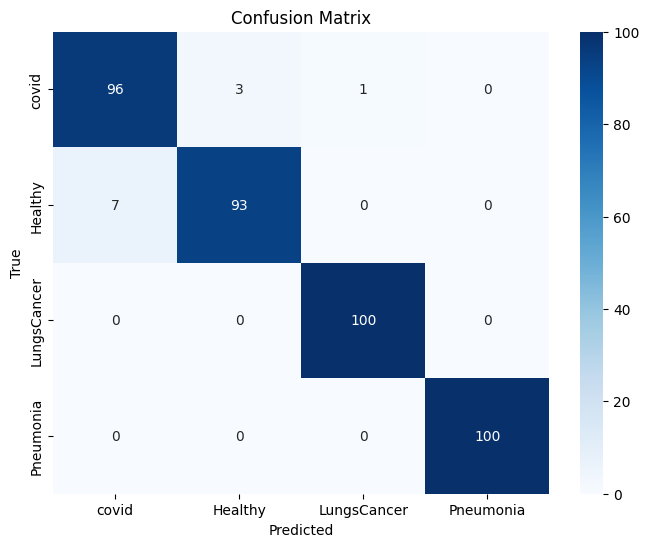

In [19]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

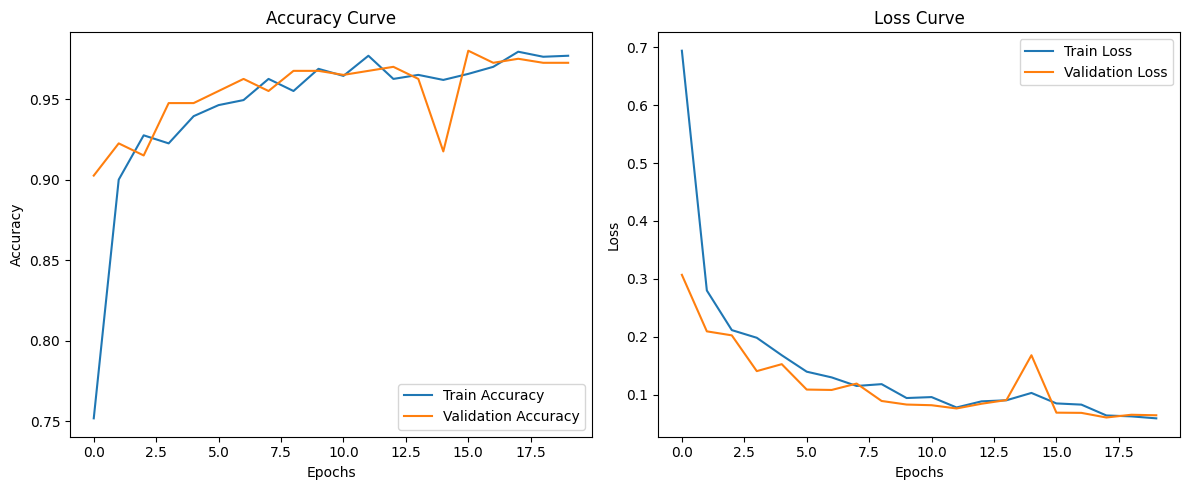

In [20]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()